#Treinando uma rede neural com Pytorch

In [1]:
import torch
from torch import nn

In [2]:
if torch.cuda.is_available():
  device = torch.device('cuda')
else:
  device = torch.device('cpu')
print(device)

cuda


In [3]:
from sklearn import datasets

wine = datasets.load_wine()
data = wine.data
target = wine.target

print(data.shape,target.shape)
print(wine.feature_names,wine.target_names)


(178, 13) (178,)
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline'] ['class_0' 'class_1' 'class_2']


178 amostras com 13 características e 178 rótulos

In [4]:
class WineClassifier(nn.Module):
  def __init__(self, input_size, hidden_size, out_size):
    super(WineClassifier,self).__init__()

    self.hidden = nn.Linear(input_size,hidden_size)
    self.relu = nn.ReLU()
    self.out = nn.Linear(hidden_size, out_size)
    self.softmax = nn.Softmax() #Transforma as saídas em distribuições de probabilidades

  def forward(self,X): #X é a entrada, self indica que pertence a classe
    feature = self.relu(self.hidden(X)) #ativação da camada intermediária
    output = self.softmax(self.out(feature)) #ativação camada saída

    return output
input_size = data.shape[1]
hidden_size = 32 #escolha arbitrária
out_size = len(wine.target_names)

net = WineClassifier(input_size,hidden_size,out_size).to(device) #cast na GPU






In [5]:
print(net)

WineClassifier(
  (hidden): Linear(in_features=13, out_features=32, bias=True)
  (relu): ReLU()
  (out): Linear(in_features=32, out_features=3, bias=True)
  (softmax): Softmax(dim=None)
)


##Classificação

O primeiro passo é instanciar uma função de perda de sua escolha, usaremos a Cross entropy por ser um problema de classificação de 3 classes.

In [6]:
criterion = nn.CrossEntropyLoss().to(device)

Aqui fazemos o cast dos dados para tensores e extraimos as predições y' da rede.

In [7]:
Xtensor = torch.from_numpy(data).float() #float64 é o double, precisamos apenas de float normal, por isso essa alteração
Ytensor = torch.from_numpy(target)

print(Xtensor.dtype,Ytensor.dtype)
#Cast na GPU
Xtensor = Xtensor.to(device)
Ytensor = Ytensor.to(device)





torch.float32 torch.int64


In [8]:
pred = net(Xtensor)#Saída da rede dada a entrada

print(pred.shape) #X = 178 amostras, saída com 3 pois temos 3 classes diferentes de probabilidade

torch.Size([178, 3])


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1739: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


In [9]:
print(pred.shape, Ytensor.shape)

torch.Size([178, 3]) torch.Size([178])


As funções de perda implementadas no Pytorch esperam o seguinte padrão de chamada:
loss = criterion(prediction, target)
Vale lembrar que cada função de perda possui especificidades quanto às dimensões dos seus parâmetros. Para a Cross Entropy:


*   prediction: (N,C)
*   target:(N)

N = Número de amostras

C = número de classes



In [10]:
print(pred[0].data, Ytensor[0].data)

tensor([2.7646e-07, 9.9899e-01, 1.0089e-03], device='cuda:0') tensor(0, device='cuda:0')


In [11]:
loss = criterion(pred, Ytensor)
print(loss) #Média da perda para os valores

tensor(1.1701, device='cuda:0', grad_fn=<NllLossBackward0>)


#Regressão

Vamos trabalhar com o dataset de diabetes.

In [12]:
from sklearn import datasets

diabetes = datasets.load_diabetes()
data = diabetes.data
target = diabetes.target

print(data.shape,target.shape)

print(diabetes.feature_names, target[0])

(442, 10) (442,)
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6'] 151.0


In [13]:
class DiabetesClassifier(nn.Module):
  def __init__(self, input_size, hidden_size, out_size):
    super(DiabetesClassifier,self).__init__()

    self.hidden = nn.Linear(input_size,hidden_size)
    self.relu = nn.ReLU()
    self.out = nn.Linear(hidden_size, out_size)
    self.softmax = nn.Softmax() #Transforma as saídas em distribuições de probabilidades

  def forward(self,X): #X é a entrada, self indica que pertence a classe
    feature = self.relu(self.hidden(X)) #ativação da camada intermediária
    output = self.softmax(self.out(feature)) #ativação camada saída

    return output
input_size = data.shape[1]
hidden_size = 32 #escolha arbitrária
out_size = 1 # apenas retorna 1 variável, que é o valor da progressão da diabetes

net = DiabetesClassifier(input_size,hidden_size,out_size).to(device) #cast na GPU






Para solucionar problemas de regressão, as funções de perda correspondentes esperam que ambos o rótulo e a predição tenha a mesma dimensionalidade.Não se trata mais de um problema categórico.
Portanto, vamos simular um problema de regressão e aplicar a MSELoss

In [14]:
criterion = nn.MSELoss().to(device)
#Cast na GPU

Xtensor = torch.from_numpy(data).float().to(device)
Ytensor = torch.from_numpy(target).float().to(device)

print(Xtensor.dtype,Ytensor.dtype)
print(Xtensor.shape, Ytensor.shape)


torch.float32 torch.float32
torch.Size([442, 10]) torch.Size([442])


In [15]:
pred = net(Xtensor)
print(pred.shape) #442 amostras com 1 saída, é essencial que o rótulo(Ytensor) e a pred tenham a mesma dimensão

torch.Size([442, 1])


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1739: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


Temos 2 opções, adicionar unsqueeze em algum pra adicionar 1 dimensão ou no outro.

In [16]:
loss = criterion(pred.squeeze(), Ytensor)
print(loss.data)

tensor(28771.2168, device='cuda:0')


In [17]:
criterion = nn.L1Loss().to(device)
# Resultado da MSE: tensor(28771.2148, device='cuda:0')
# Resultado da L1: tensor(151.1335, device='cuda:0')
loss = criterion(pred.squeeze(), Ytensor)
print(loss.data)


tensor(151.1335, device='cuda:0')


Como o nosso modelo não foi treinado, ou seja, apenas foi inicializado com valores aleatórios, é esperado um baixíssimo desempenho com altos índices de erro. Podemos notar que o critério quadrático penaliza muito mais os erros, apresentando um erro 190x maior que a função de distância absoluta. Esse comportamento é ideal para uma boa convergência, a menos que o seu modelo possua outliers.

##Otimizando a rede

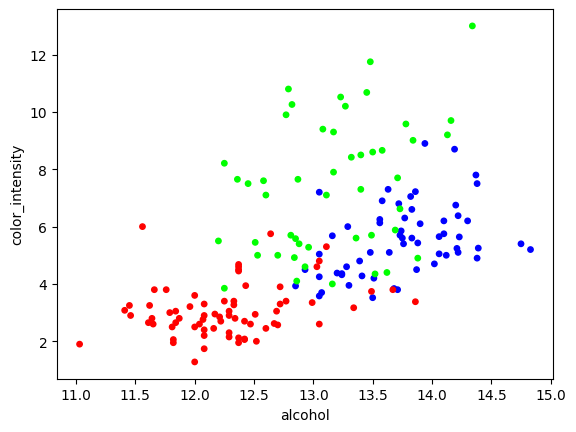

In [18]:
from sklearn import datasets
import matplotlib.pyplot as plt

features =  [0,9]
wine  = datasets.load_wine()
data = wine.data[:,features]
targets = wine.target

plt.scatter(data[:,0], data[:,1],c=targets,s=15, cmap=plt.cm.brg)
plt.xlabel(wine.feature_names[features[0]])
plt.ylabel(wine.feature_names[features[1]])
plt.show()



##Normalização


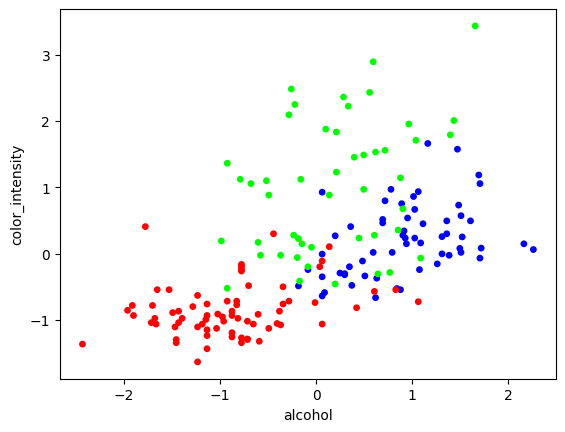

In [19]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data = scaler.fit_transform(data)
plt.scatter(data[:,0], data[:,1],c=targets,s=15, cmap=plt.cm.brg)
plt.xlabel(wine.feature_names[features[0]])
plt.ylabel(wine.feature_names[features[1]])
plt.show()


##Instanciando a rede

In [20]:
import torch
from torch import nn

if torch.cuda.is_available():
  device = torch.device('cuda')
else:
  device = torch.device('cpu')

print(device)


input_size = data.shape[1]
hidden_size=32
out_size = len(wine.target_names) #n de classes

net = nn.Sequential(
    nn.Linear(input_size,hidden_size),
    nn.ReLU(),
    nn.Linear(hidden_size, out_size),
    nn.Softmax()

)
net = net.to(device)

cuda


##Visualizando a fronteira de decisão

Código complementar do github:https://github.com/camilalaranjeira/Neural-Lectures/blob/master/XOR_Problem.ipynb

In [21]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def plot_boundary(X, y, model):
  x_min, x_max = X[:, 0].min()-0.1, X[:, 0].max()+0.1
  y_min, y_max = X[:, 1].min()-0.1, X[:, 1].max()+0.1

  spacing = min(x_max - x_min, y_max - y_min) / 100

  XX, YY = np.meshgrid(np.arange(x_min, x_max, spacing),
                       np.arange(y_min, y_max, spacing))

  data = np.hstack((XX.ravel().reshape(-1,1),
                    YY.ravel().reshape(-1,1)))

  # For binary problems
  # db_prob = model(Variable(torch.Tensor(data)).cuda() )
  # clf = np.where(db_prob.cpu().data < 0.5,0,1)

  # For multi-class problems
  db_prob = model(torch.Tensor(data).to(device) )
  clf = np.argmax(db_prob.cpu().data.numpy(), axis=-1)

  Z = clf.reshape(XX.shape)

  plt.contourf(XX, YY, Z, cmap=plt.cm.brg, alpha=0.5)
  plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k', s=25,cmap=plt.cm.brg)

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1739: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


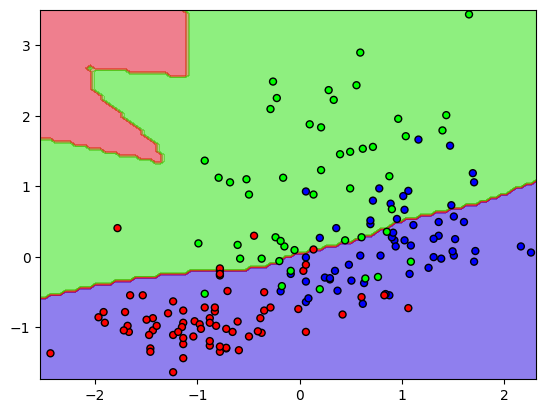

In [22]:
plot_boundary(data, targets,net)

##Torch.optim

A implementação dos principais algoritmos de NN são feitas por essa biblioteca.
O primeiro passo é instanciar o otimizador. De acordo com o pacote optim, basta chamar o otimizador escolhido, passando como parâmetro:


*   Os parâmetros da rede que será otimizada (net.parameters( ) )
*   A taxa de aprendizado

A depender do otimizador, pode ser necessário alimentar outros parâmetros, mas esses dois são obrigatórios!

Utilizando a Descida do Gradiente, implementada pelo otimizador optim.SGD(*Stochastic Gradient Descent*):


In [23]:
from torch import optim
#Função de perda
criterion = nn.CrossEntropyLoss().to(device)

#Otimizador: Descida do Gradiente

optimizer = optim.SGD(net.parameters(), lr = 1e-3)




##Cast dos dados

In [24]:
X = torch.FloatTensor(data).to(device)
Y = torch.LongTensor(targets).to(device)


##Treinando um modelo

O treinamento consiste nas etapas que vimos na aula teórica. Aqui vamos relacionar cada etapa ao seu código correspondente.

Forward

Alimentar os dados para a rede

pred = net(X)

Calcular a função de custo

loss = criterion(pred, y)

Backpropagation

Calcular o gradiente

loss.backward()

Atualizar os pesos

optimizer.step()

A princípio não vamos falar de procedimentos adequados de treinamento. Vamos apenas realizar as etapas de treinamento e ver o que acontece.

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1739: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


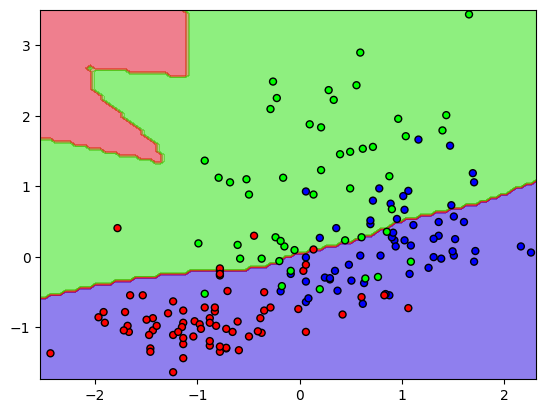

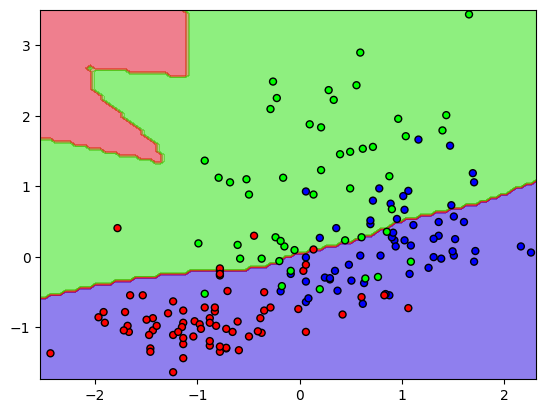

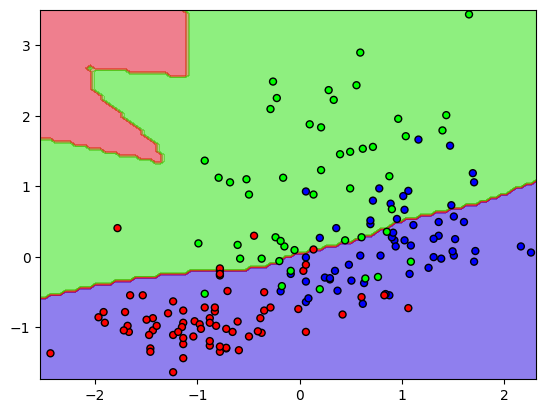

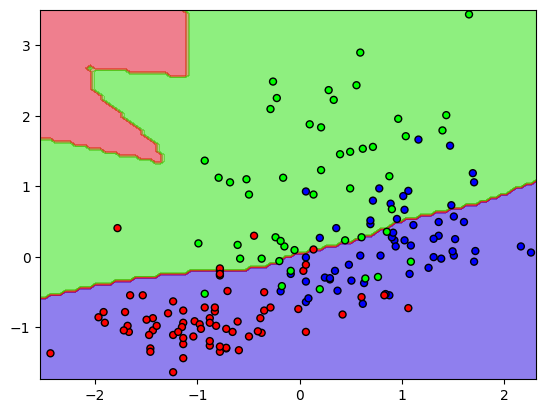

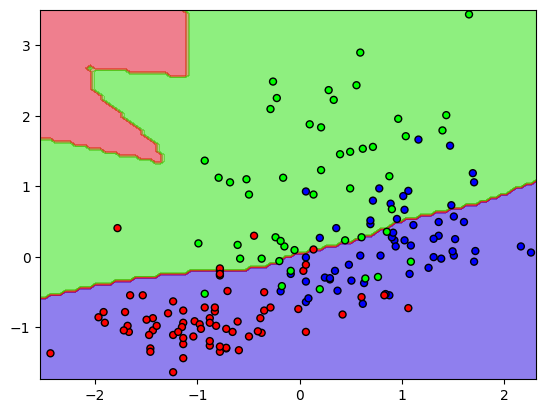

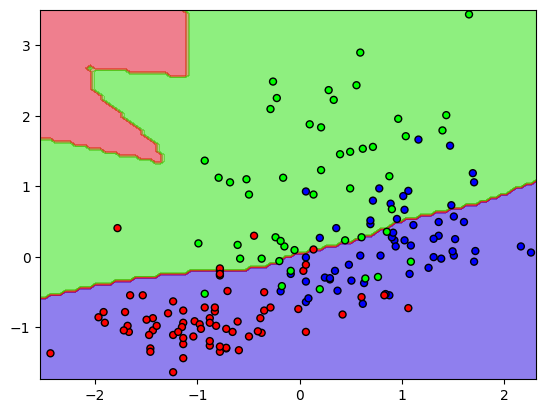

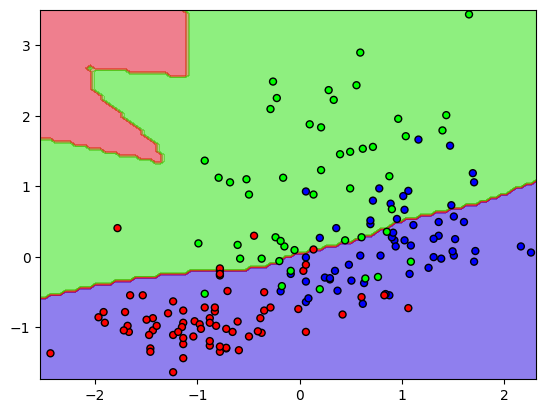

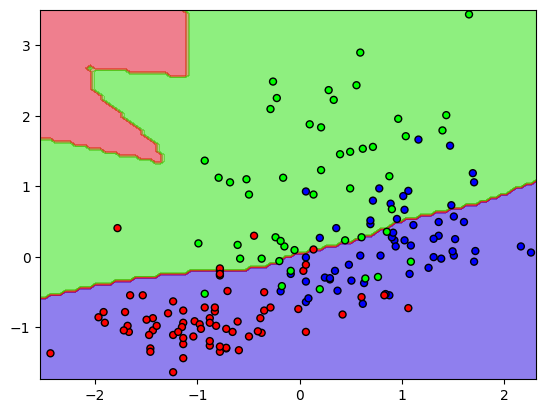

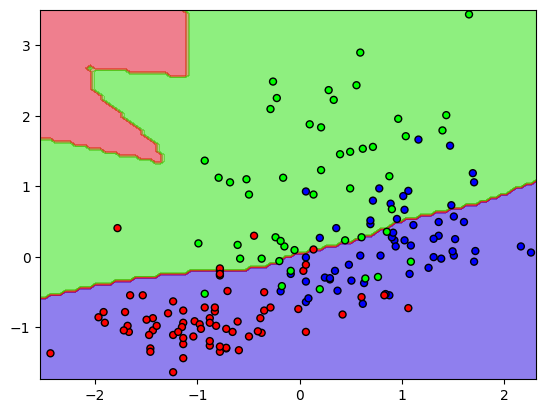

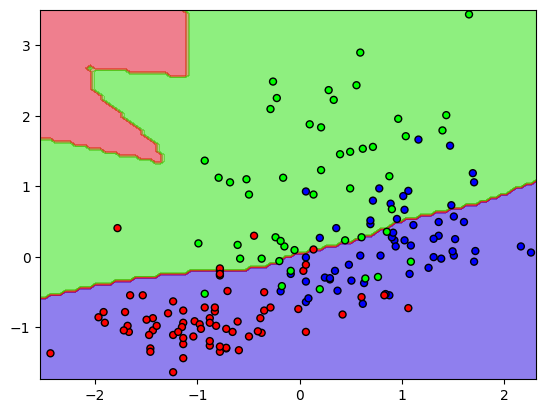

In [25]:
for i in range(1000):
  #Forward
  pred = net(X)
  loss = criterion(pred, Y)

  #Backward
  loss.backward()#calcula o gradiente
  optimizer.step
  if i % 100 == 0:
    plt.figure()
    plot_boundary(data, targets,net)

##Fluxo de treinamento

In [26]:
import torch
from torch import nn,optim
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

args = {
    'batch_size': 32,
    'num_workers': 4,
    'num_classes': 10,
    'lr': 1e-6,
    'weight_decay': 1e-4,
    'num_epochs': 30
}
if torch.cuda.is_available():
  args['device'] = torch.device('cuda')
else:
  args['device'] = torch.device('gpu')
print(args['device'])

cuda


In [27]:
train_set = datasets.MNIST('./',
                           train=True,
                           transform = transforms.ToTensor(),
                           download=True)
test_set = datasets.MNIST('./',
                           train=False,
                           transform = transforms.ToTensor(),
                           download=False)

print('Amostras de treino: '+str(len(train_set)))
print('Amostras de teste: '+str(len(test_set)))

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 482kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.88MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.6MB/s]

Amostras de treino: 60000
Amostras de teste: 10000


Cada  dataset possui uma implementação especifica no pytorch. Verifique o type da variável que recebeu os dados e veja que se refere a uma classe específica do dataset.
No entanto, o item de qualquer dataset sempre será uma tupla (dado,rótulo)

In [28]:
print(type(train_set))
print(type(train_set[0]))

<class 'torchvision.datasets.mnist.MNIST'>
<class 'tuple'>


In [29]:
print(train_set[0])

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000

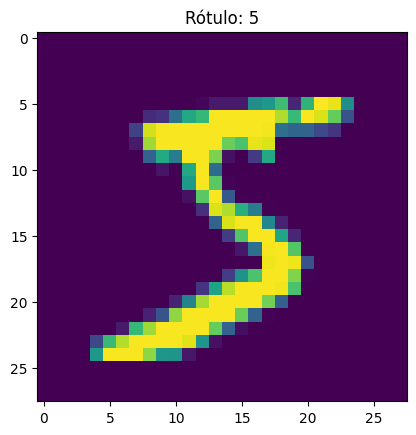

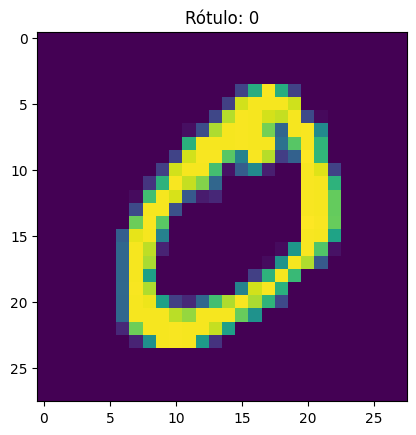

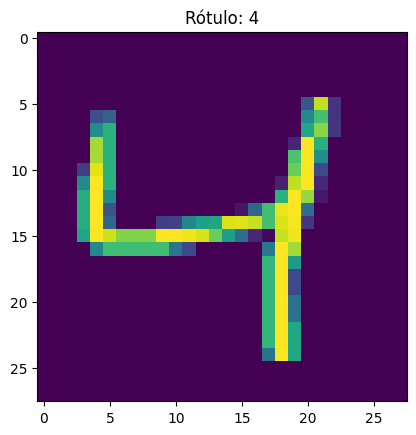

In [30]:
for i in range(3):
  dado, rotulo = train_set[i]

  plt.figure()
  plt.imshow(dado[0])
  plt.title('Rótulo: ' + str(rotulo))



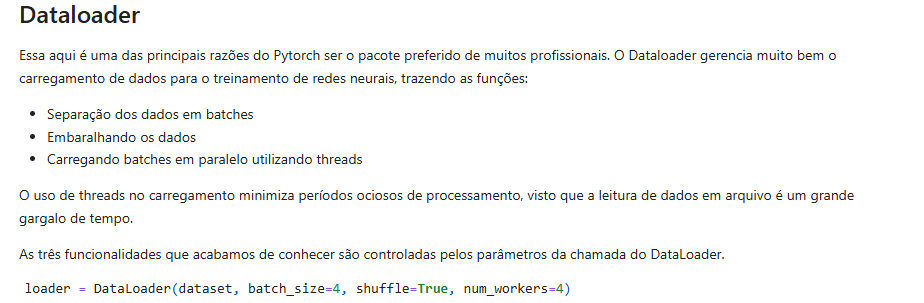

In [31]:
train_loader = DataLoader(train_set,
                          batch_size=args['batch_size'],
                          shuffle=True,
                          num_workers=args['num_workers'])
test_loader = DataLoader(test_set,
                          batch_size=args['batch_size'],
                          shuffle=True,
                          num_workers=args['num_workers'])

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


O objeto retornado é um iterador, podendo ser utilizado para iterar em loops, mas não suportando indexação!

torch.Size([32, 1, 28, 28]) torch.Size([32])


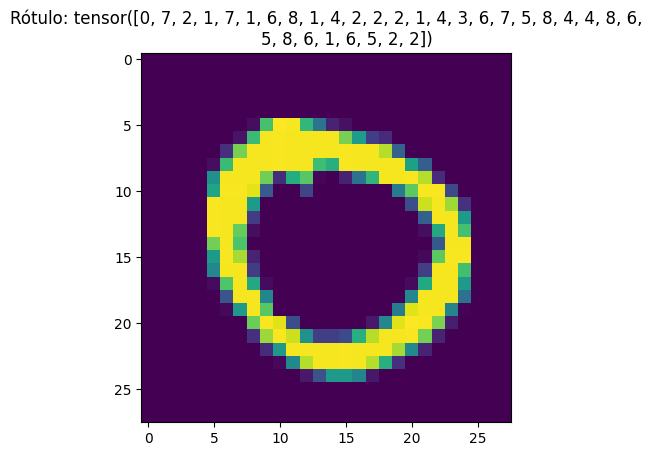

In [32]:
for batch in train_loader:
  dado, rotulo = batch
  print(dado.size(), rotulo.size())

  plt.imshow(dado[0][0])
  plt.title('Rótulo: ' + str(rotulo))

  break

##Fluxo de treinamento

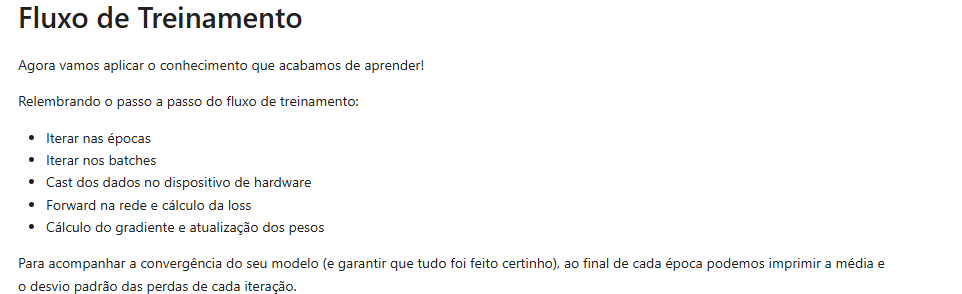

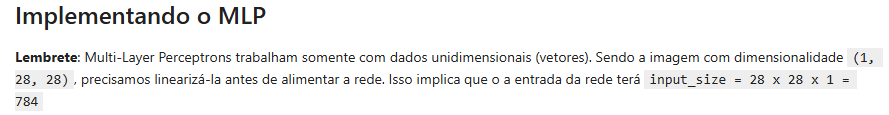

In [33]:
class MLP(nn.Module):

  def __init__(self, input_size, hidden_size, out_size):
    super(MLP, self).__init__()

    self.features  = nn.Sequential(
                      nn.Linear(input_size, hidden_size),
                      nn.ReLU(),
                      nn.Linear(hidden_size, hidden_size),
                      nn.ReLU()
                    )
    self.out     = nn.Linear(hidden_size, out_size)
    self.softmax = nn.Softmax()

  def forward(self, X):

    X = X.view(X.size(0), -1) #redimensiona, mantém a primeira dimensão e lineariza o resto

    feature = self.features(X)
    output  = self.softmax(self.out(feature))

    return output

input_size  = 28 * 28
hidden_size = 128
out_size    = 10 #classes (digitos de 0 a 9)

torch.manual_seed(42)
net = MLP(input_size, hidden_size, out_size).to(args['device']) #cast na GPU


##Definindo loss e otimizador

In [34]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr = args['lr'], weight_decay=args['weight_decay'])

In [35]:
for epoch in range(args['num_epochs']):
  epoch_loss =[]
  for batch in train_loader:
    dado, rotulo = batch

    #Cast na GPU
    dado = dado.to(args['device'])
    rotulo = rotulo.to(args['device'])

    #Forward
    pred = net(dado)
    loss = criterion(pred,rotulo)
    epoch_loss.append(loss.cpu().data)

    #Backward
    loss.backward()
    optimizer.step()

  epoch_loss= np.asarray(epoch_loss)

  print("Epoca %d, Loss: %.4f +|- %.4f" % (epoch,epoch_loss.mean(), epoch_loss.std()))


Epoca 0, Loss: 2.2974 +|- 0.0036


KeyboardInterrupt: 

#Trabalhando com nossos próprios dados

In [33]:

import torch
from torch import nn
from torch import optim

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from sklearn import metrics
from sklearn.preprocessing import StandardScaler

import pandas as pd
import numpy as np
import time
import os


import matplotlib.pyplot as plt
%matplotlib inline

# Configurando hiperparâmetros.
args = {
    'epoch_num': 200,     # Número de épocas.
    'lr': 5e-5,           # Taxa de aprendizado.
    'weight_decay': 5e-4, # Penalidade L2 (Regularização).
    'num_workers': 3,     # Número de threads do dataloader.
    'batch_size': 20,     # Tamanho do batch.
}

if torch.cuda.is_available():
    args['device'] = torch.device('cuda')
else:
    args['device'] = torch.device('cpu')

print(args['device'])

cuda


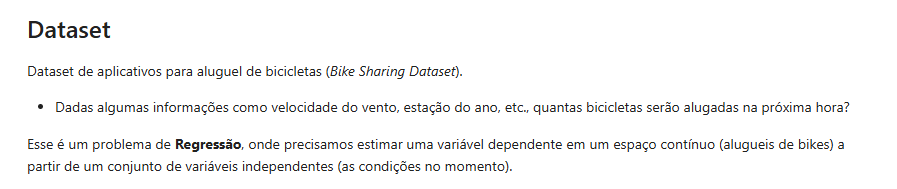

https://archive.ics.uci.edu/ml/datasets/Bike+Sharing+Dataset

In [2]:
! wget https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip
! unzip Bike-Sharing-Dataset.zip

--2025-07-01 23:17:49--  https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘Bike-Sharing-Dataset.zip’

Bike-Sharing-Datase     [   <=>              ] 273.43K   426KB/s    in 0.6s    

2025-07-01 23:17:50 (426 KB/s) - ‘Bike-Sharing-Dataset.zip’ saved [279992]

Archive:  Bike-Sharing-Dataset.zip
  inflating: Readme.txt              
  inflating: day.csv                 
  inflating: hour.csv                


##Visualizando os dados

In [3]:
!ls

Bike-Sharing-Dataset.zip  day.csv  hour.csv  Readme.txt  sample_data


In [4]:
df = pd.read_csv('hour.csv')
print(len(df))
df.head()

17379


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


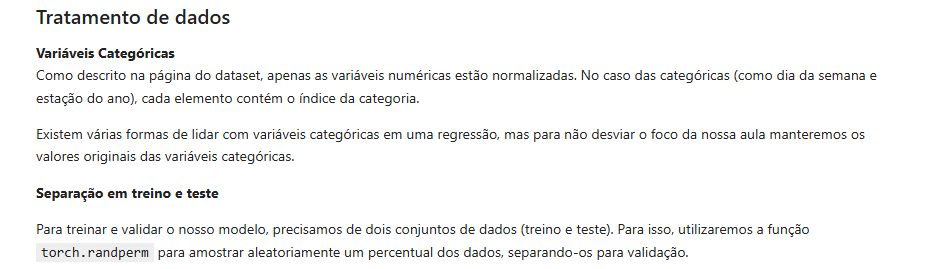

Documentação: https://pytorch.org/docs/stable/torch.html#torch.randperm

In [5]:
torch.randperm(10)

tensor([2, 1, 5, 8, 9, 3, 0, 7, 6, 4])

In [34]:
# Train/Test split
torch.manual_seed(1)
indices = torch.randperm(len(df)).tolist()

train_size = int(0.8*len(df))
df_train = df.iloc[indices[:train_size]]
df_test  = df.iloc[indices[train_size:]]

print(len(df_train), len(df_test))
display(df_test.head())

df_train.to_csv('bike_train.csv',index=False)
df_test.to_csv('bike_test.csv',index=False)
!ls

13903 3476


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
12663,12664,2012-06-16,2,1,6,20,0,6,0,2,0.66,0.6212,0.47,0.1940,123,229,352
1801,1802,2011-03-20,1,0,3,18,0,0,0,1,0.38,0.3939,0.40,0.3582,58,98,156
16567,16568,2012-11-28,4,1,11,1,0,3,1,2,0.26,0.2576,0.75,0.2239,0,12,12
8817,8818,2012-01-08,1,1,1,5,0,0,0,2,0.32,0.3333,0.49,0.1045,0,2,2
2608,2609,2011-04-23,2,0,4,14,0,6,0,1,0.58,0.5455,0.78,0.3582,182,209,391


Bike-Sharing-Dataset.zip  bike_train.csv  hour.csv    sample_data
bike_test.csv		  day.csv	  Readme.txt


In [7]:
display(df_test.head())

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
12663,12664,2012-06-16,2,1,6,20,0,6,0,2,0.66,0.6212,0.47,0.1940,123,229,352
1801,1802,2011-03-20,1,0,3,18,0,0,0,1,0.38,0.3939,0.40,0.3582,58,98,156
16567,16568,2012-11-28,4,1,11,1,0,3,1,2,0.26,0.2576,0.75,0.2239,0,12,12
8817,8818,2012-01-08,1,1,1,5,0,0,0,2,0.32,0.3333,0.49,0.1045,0,2,2
2608,2609,2011-04-23,2,0,4,14,0,6,0,1,0.58,0.5455,0.78,0.3582,182,209,391


In [8]:
df_train.to_csv('bike_train.csv', index=False)
df_test.to_csv('bike_test.csv', index=False)
!ls

Bike-Sharing-Dataset.zip  bike_train.csv  hour.csv    sample_data
bike_test.csv		  day.csv	  Readme.txt


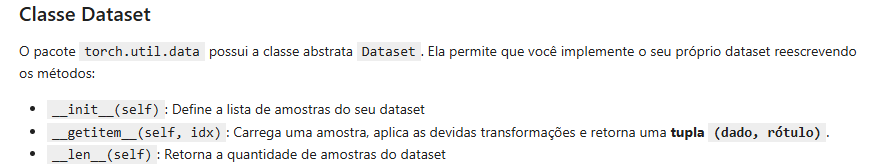

Tutorial completo do PyTorch: https://pytorch.org/tutorials/beginner/data_loading_tutorial.html

In [35]:
class Bicicletinha(Dataset):
  def __init__(self, csv_path, scaler_feat=None, scaler_label=None):

    self.dados = pd.read_csv(csv_path).to_numpy()

  def __getitem__(self, idx):

    sample = self.dados[idx][2:14]
    label  = self.dados[idx][-1:]

    # converte para tensor
    sample = torch.from_numpy(sample.astype(np.float32))
    label  = torch.from_numpy(label.astype(np.float32))

    return sample, label

  def __len__(self):
    return len(self.dados)

Visualizando uma amostra dos nossos dados

In [36]:

dataset = Bicicletinha('bike_train.csv')
dado, rotulo = dataset[0]
print(rotulo)
print(dado)

tensor([373.])
tensor([ 4.0000,  1.0000, 11.0000, 19.0000,  0.0000,  4.0000,  1.0000,  1.0000,
         0.3800,  0.3939,  0.2700,  0.3582])


In [37]:

train_set = Bicicletinha('bike_train.csv')
test_set  = Bicicletinha('bike_test.csv')

print('Tamanho do treino: ' + str(len(train_set)) + ' amostras')
print('Tamanho do teste: ' + str(len(test_set)) + ' amostras')


Tamanho do treino: 13903 amostras
Tamanho do teste: 3476 amostras


In [38]:
train_loader = DataLoader(train_set,
                          args['batch_size'],
                          num_workers=args['num_workers'],
                          shuffle=True)
test_loader = DataLoader(test_set,
                         args['batch_size'],
                         num_workers=args['num_workers'],
                         shuffle=False)


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 3 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [39]:

for batch in test_loader:

  dado, rotulo = batch
  print('## Dimensionalidade do batch ##')

  print(dado.size(), rotulo.size())

  break

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 3 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


## Dimensionalidade do batch ##
torch.Size([20, 12]) torch.Size([20, 1])


##Tratamento de dados

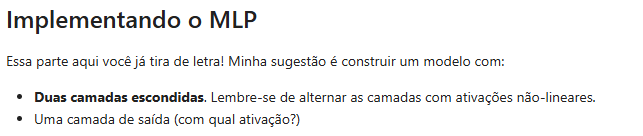

In [40]:

class MLP(nn.Module):

  def __init__(self, input_size, hidden_size, out_size):
    super(MLP, self).__init__()

    self.features = nn.Sequential(
          nn.Linear(input_size, hidden_size),
          nn.ReLU(),
          nn.Linear(hidden_size, hidden_size),
          nn.ReLU(),
    )

    self.classifier = nn.Sequential(
        nn.Linear(hidden_size, out_size),
        nn.ReLU(),
    )

  def forward(self, X):

    hidden = self.features(X)
    output = self.classifier(hidden)

    return output

input_size  = train_set[0][0].size(0)
hidden_size = 128
out_size    = 1 # variaveis preditas bicicleta softmax some

net = MLP(input_size, hidden_size, out_size).to(args['device'])
print(net)

MLP(
  (features): Sequential(
    (0): Linear(in_features=12, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
  )
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=1, bias=True)
    (1): ReLU()
  )
)


##Definindo loss e otimizador

In [41]:
criterion = nn.L1Loss().to(args['device'])
optimizer = optim.Adam(net.parameters(), lr=args['lr'], weight_decay=args['weight_decay'])

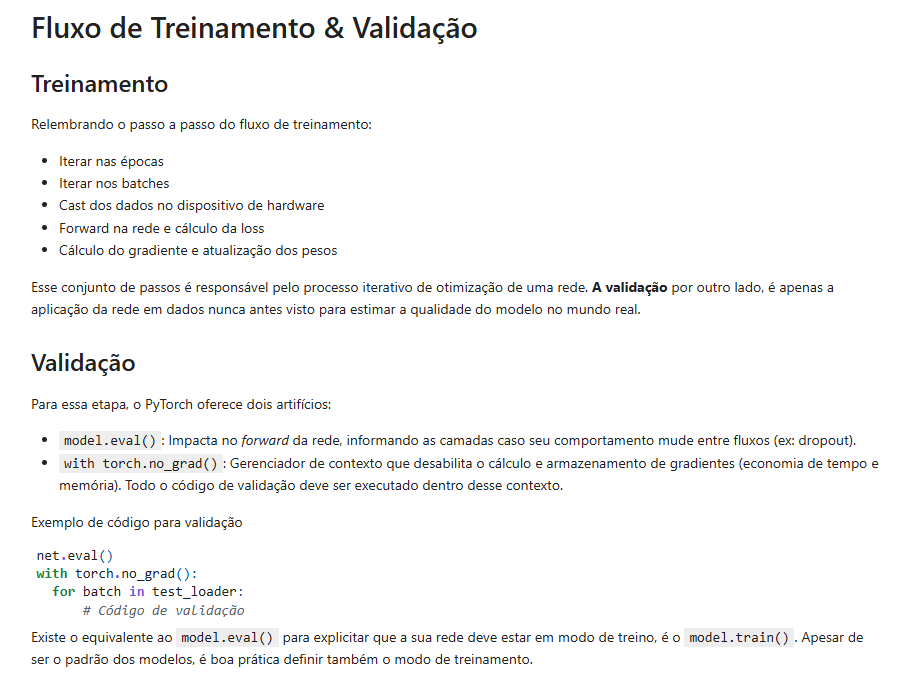

In [42]:
def train(train_loader, net, epoch):

  # Training mode
  net.train()

  start = time.time()

  epoch_loss  = []
  for batch in train_loader:

    dado, rotulo = batch

    # Cast do dado na GPU
    dado = dado.to(args['device'])
    rotulo = rotulo.to(args['device'])

    # Forward
    ypred = net(dado)
    loss = criterion(ypred, rotulo)
    epoch_loss.append(loss.cpu().data)

    # Backpropagation
    loss.backward()
    optimizer.step()

  epoch_loss = np.asarray(epoch_loss)

  end = time.time()
  print('#################### Train ####################')
  print('Epoch %d, Loss: %.4f +/- %.4f, Time: %.2f' % (epoch, epoch_loss.mean(), epoch_loss.std(), end-start))

  return epoch_loss.mean()

In [43]:
def validate(test_loader, net, epoch):

  # Evaluation mode
  net.eval()

  start = time.time()

  epoch_loss  = []

  with torch.no_grad():
    for batch in test_loader:

      dado, rotulo = batch

      # Cast do dado na GPU
      dado = dado.to(args['device'])
      rotulo = rotulo.to(args['device'])

      # Forward
      ypred = net(dado)
      loss = criterion(ypred, rotulo)
      epoch_loss.append(loss.cpu().data)

  epoch_loss = np.asarray(epoch_loss)

  end = time.time()
  print('********** Validate **********')
  print('Epoch %d, Loss: %.4f +/- %.4f, Time: %.2f\n' % (epoch, epoch_loss.mean(), epoch_loss.std(), end-start))

  return epoch_loss.mean()


In [ ]:

train_losses, test_losses = [], []
for epoch in range(args['epoch_num']):

  # Train
  train_losses.append(train(train_loader, net, epoch))

  # Validate
  test_losses.append(validate(test_loader, net, epoch))

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 3 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


#################### Train ####################
Epoch 0, Loss: 82.7928 +/- 23.4941, Time: 2.55


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 3 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


********** Validate **********
Epoch 0, Loss: 83.6209 +/- 19.8845, Time: 0.46

#################### Train ####################
Epoch 1, Loss: 82.8046 +/- 22.4700, Time: 2.49


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 3 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


...

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 3 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


#################### Train ####################
Epoch 40, Loss: 67.5343 +/- 19.0903, Time: 2.46


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 3 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


********** Validate **********
Epoch 40, Loss: 64.7462 +/- 19.1159, Time: 0.66



/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 3 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [ ]:

Xtest = torch.stack([tup[0] for tup in test_set])
Xtest = Xtest.to(args['device'])

ytest = torch.stack([tup[1] for tup in test_set])
ypred = net(Xtest).cpu().data

data = torch.cat((ytest, ypred), axis=1)

df_results = pd.DataFrame(data, columns=['ypred', 'ytest'])
df_results.head(20)

In [ ]:

plt.figure(figsize=(20, 9))
plt.plot(train_losses, label='Train')
plt.plot(test_losses, label='Test', linewidth=3, alpha=0.5)
plt.xlabel('Epochs', fontsize=16)
plt.ylabel('Loss', fontsize=16)
plt.title('Convergence', fontsize=16)
plt.legend()
plt.show()